In [1]:
import scipy
import matplotlib.pyplot as plt
import numpy as np
import csv
import time
import pandas as pd
from datetime import datetime
from scipy.optimize import curve_fit, minimize

In [2]:
def pt_func_p_adj(t, a, gamma, c, d):
    # Exponential based on Clausius-Clapeyron relation, use xenon normal boiling point params for initial guess
    # a = 1 bar, gamma = 1500, c = 1/165.1 K
    return a*np.exp(gamma*((1/t)-c))+d
def pt_func_p(t, a, gamma, c):
    # Exponential pressure function for P-T curve
    return a*np.exp(t*gamma)+c
def pt_func_t(p, a, gamma, c):
    # Exponential temperature function for P-T curve
    return (1/gamma)*np.log((p-c)/a)

In [ ]:
timestamp_temp = []
temp_temp = []
min_time = datetime(2026, 1, 16, 0, 0, 0)
max_time = datetime(2026, 1, 20, 23, 59, 59)
min_time_dope = datetime(2026, 1, 22, 0, 50, 0)
max_time_dope = datetime(2026, 1, 23, 17, 46, 46)
min_inj = datetime(2026, 1, 22, 21, 56, 22)
max_inj = datetime(2026, 1, 23, 1, 30, 0)
min_time_post = datetime(2026, 4, 30, 0, 0, 0)
max_time_post = datetime(2026, 4, 30, 21, 0, 0)
#min_time_post2 = datetime(2026, 2, 28, 23, 0, 0)
#max_time_post2 = datetime(2026, 3, 2, 16, 0, 0)
format_pattern = "%Y-%m-%d %H:%M:%S"
data_lib = '/Users/bfeike/Documents'
with open(f'{data_lib}/tpc_temp.csv', mode='r', newline='') as file:
    reader = csv.reader(file)
    for row in reader:
        ts = datetime.strptime(row[0], format_pattern)
        if ts > min_time and ts < max_time:
            timestamp_temp.append(row[0])
            temp_temp.append(row[1])
            
timestamp_pressure = []
pressure_pressure = []
with open(f'{data_lib}/omega_pressure.csv', mode='r', newline='') as file:
    reader = csv.reader(file)
    for row in reader:
        ts = datetime.strptime(row[0], format_pattern)
        if ts > min_time and ts < max_time:
            timestamp_pressure.append(row[0])
            pressure_pressure.append(row[1])

timestamp_t_dope = []
temp_dope = []
with open(f'{data_lib}/tpc_temp.csv', mode='r', newline='') as file:
    reader = csv.reader(file)
    for row in reader:
        ts = datetime.strptime(row[0], format_pattern)
        if ts > min_time_dope and ts < max_time_dope:
            if not (ts > min_inj and ts < max_inj):
                timestamp_t_dope.append(row[0])
                temp_dope.append(row[1])

timestamp_p_dope = []
pressure_dope = []
with open(f'{data_lib}/omega_pressure.csv', mode='r', newline='') as file:
    reader = csv.reader(file)
    for row in reader:
        ts = datetime.strptime(row[0], format_pattern)
        if ts > min_time_dope and ts < max_time_dope:
            if not (ts > min_inj and ts < max_inj):
                timestamp_p_dope.append(row[0])
                pressure_dope.append(row[1])

timestamp_t_post = []
temp_post = []
with open(f'{data_lib}/tpc_temp.csv', mode='r', newline='') as file:
    reader = csv.reader(file)
    for row in reader:
        ts = datetime.strptime(row[0], format_pattern)
        if ts > min_time_post and ts < max_time_post:
            timestamp_t_post.append(row[0])
            temp_post.append(row[1])

timestamp_p_post = []
pressure_post = []
with open(f'{data_lib}/omega_pressure.csv', mode='r', newline='') as file:
    reader = csv.reader(file)
    for row in reader:
        ts = datetime.strptime(row[0], format_pattern)
        if ts > min_time_post and ts < max_time_post:
            timestamp_p_post.append(row[0])
            pressure_post.append(row[1])

In [65]:
dt = datetime.fromtimestamp(0)
ts_cut = []
ts_dope_cut = []
ts_post_cut = []
ts_post2_cut = []
temp_cut = []
temp_dope_cut = []
temp_post_cut = []
temp_post2_cut = []
pressure_cut = []
pressure_dope_cut = []
pressure_post_cut = []
pressure_post2_cut = []

ts_cut.append(timestamp_pressure[0::100])
temp_cut.append(temp_temp[0::100])
pressure_cut.append(pressure_pressure[0::100])
ts_dope_cut.append(timestamp_p_dope[0::100])
temp_dope_cut.append(temp_dope[0::100])
pressure_dope_cut.append(pressure_dope[0::100])
ts_post_cut.append(timestamp_p_post[0::50])
temp_post_cut.append(temp_post)
pressure_post_cut.append(pressure_post)
unix_timestamps = pd.to_datetime(ts_cut[0]).astype(np.int64)//10**9
unix_timestamps_dope = pd.to_datetime(ts_dope_cut[0]).astype(np.int64)//10**9
unix_timestamps_post = pd.to_datetime(ts_post_cut[0]).astype(np.int64)//10**9

In [66]:
LV_sat = np.array([[ 161.4   ,    0.817 ],
       [ 161.41  ,    0.818 ],
       [ 161.85  ,    0.8399],
       [ 162.35  ,    0.8653],
       [ 162.85  ,    0.8913],
       [ 163.35  ,    0.918 ],
       [ 163.85  ,    0.9452],
       [ 164.35  ,    0.9731],
       [ 164.85  ,    1.002 ],
       [ 165.35  ,    1.031 ],
       [ 165.85  ,    1.061 ],
       [ 166.35  ,    1.091 ],
       [ 166.85  ,    1.122 ],
       [ 167.35  ,    1.154 ],
       [ 167.85  ,    1.186 ],
       [ 168.35  ,    1.22  ],
       [ 168.85  ,    1.254 ],
       [ 169.35  ,    1.288 ],
       [ 169.85  ,    1.324 ],
       [ 170.35  ,    1.36  ],
       [ 170.85  ,    1.396 ],
       [ 171.35  ,    1.434 ],
       [ 171.85  ,    1.472 ],
       [ 172.35  ,    1.512 ],
       [ 172.85  ,    1.552 ],
       [ 173.35  ,    1.592 ],
       [ 173.85  ,    1.634 ],
       [ 174.35  ,    1.676 ],
       [ 174.85  ,    1.719 ],
       [ 175.35  ,    1.763 ],
       [ 175.85  ,    1.808 ],
       [ 176.35  ,    1.854 ],
       [ 176.85  ,    1.901 ],
       [ 177.35  ,    1.948 ],
       [ 177.85  ,    1.997 ],
       [ 178.35  ,    2.046 ],
       [ 178.85  ,    2.096 ],
       [ 179.35  ,    2.147 ],
       [ 179.85  ,    2.2   ],
       [ 180.35  ,    2.253 ],
       [ 180.85  ,    2.307 ],
       [ 181.35  ,    2.362 ],
       [ 181.85  ,    2.418 ],
       [ 182.35  ,    2.475 ],
       [ 182.85  ,    2.532 ],
       [ 183.35  ,    2.591 ],
       [ 183.85  ,    2.651 ],
       [ 184.35  ,    2.712 ],
       [ 184.85  ,    2.775 ],
       [ 185.35  ,    2.838 ],
       [ 185.85  ,    2.902 ],
       [ 186.35  ,    2.967 ],
       [ 186.85  ,    3.034 ],
       [ 187.35  ,    3.101 ],
       [ 187.85  ,    3.17  ],
       [ 188.35  ,    3.239 ],
       [ 188.85  ,    3.31  ],
       [ 189.35  ,    3.382 ],
       [ 189.85  ,    3.455 ],
       [ 190.35  ,    3.53  ],
       [ 190.85  ,    3.605 ],
       [ 191.35  ,    3.682 ],
       [ 191.85  ,    3.76  ],
       [ 192.35  ,    3.839 ],
       [ 192.85  ,    3.919 ],
       [ 193.35  ,    4.001 ],
       [ 193.85  ,    4.084 ],
       [ 194.35  ,    4.168 ],
       [ 194.85  ,    4.253 ],
       [ 195.35  ,    4.34  ],
       [ 195.85  ,    4.428 ],
       [ 196.35  ,    4.517 ],
       [ 196.85  ,    4.607 ],
       [ 197.35  ,    4.699 ],
       [ 197.85  ,    4.793 ],
       [ 198.35  ,    4.887 ],
       [ 198.85  ,    4.983 ],
       [ 199.35  ,    5.081 ],
       [ 199.85  ,    5.179 ],
       [ 200.35  ,    5.279 ],
       [ 200.85  ,    5.381 ],
       [ 201.35  ,    5.484 ],
       [ 201.85  ,    5.588 ],
       [ 202.35  ,    5.694 ],
       [ 202.85  ,    5.801 ],
       [ 203.35  ,    5.91  ],
       [ 203.85  ,    6.02  ],
       [ 204.35  ,    6.132 ],
       [ 204.85  ,    6.245 ],
       [ 205.35  ,    6.36  ],
       [ 205.85  ,    6.477 ],
       [ 206.35  ,    6.594 ],
       [ 206.85  ,    6.714 ],
       [ 207.35  ,    6.835 ],
       [ 207.85  ,    6.957 ],
       [ 208.35  ,    7.081 ],
       [ 208.85  ,    7.207 ],
       [ 209.35  ,    7.335 ],
       [ 209.85  ,    7.464 ],
       [ 210.35  ,    7.594 ],
       [ 210.85  ,    7.726 ],
       [ 211.35  ,    7.86  ],
       [ 211.85  ,    7.996 ],
       [ 212.35  ,    8.133 ],
       [ 212.85  ,    8.272 ],
       [ 213.35  ,    8.413 ],
       [ 213.85  ,    8.555 ],
       [ 214.35  ,    8.699 ],
       [ 214.85  ,    8.845 ],
       [ 215.35  ,    8.993 ],
       [ 215.85  ,    9.142 ],
       [ 216.35  ,    9.293 ],
       [ 216.85  ,    9.446 ],
       [ 217.35  ,    9.601 ],
       [ 217.85  ,    9.758 ],
       [ 218.35  ,    9.916 ],
       [ 218.85  ,   10.08  ],
       [ 219.35  ,   10.24  ],
       [ 219.85  ,   10.4   ],
       [ 220.35  ,   10.57  ],
       [ 220.85  ,   10.74  ],
       [ 221.35  ,   10.91  ],
       [ 221.85  ,   11.08  ],
       [ 222.35  ,   11.25  ],
       [ 222.85  ,   11.43  ],
       [ 223.35  ,   11.6   ],
       [ 223.85  ,   11.78  ],
       [ 224.35  ,   11.96  ],
       [ 224.85  ,   12.15  ],
       [ 225.35  ,   12.33  ],
       [ 225.85  ,   12.52  ],
       [ 226.35  ,   12.71  ],
       [ 226.85  ,   12.9   ],
       [ 227.35  ,   13.1   ],
       [ 227.85  ,   13.29  ],
       [ 228.35  ,   13.49  ],
       [ 228.85  ,   13.69  ],
       [ 229.35  ,   13.89  ],
       [ 229.85  ,   14.09  ],
       [ 230.35  ,   14.3   ],
       [ 230.85  ,   14.51  ],
       [ 231.35  ,   14.72  ],
       [ 231.85  ,   14.93  ],
       [ 232.35  ,   15.15  ],
       [ 232.85  ,   15.36  ],
       [ 233.35  ,   15.58  ],
       [ 233.85  ,   15.8   ],
       [ 234.35  ,   16.03  ],
       [ 234.85  ,   16.25  ],
       [ 235.35  ,   16.48  ],
       [ 235.85  ,   16.71  ],
       [ 236.35  ,   16.94  ],
       [ 236.85  ,   17.18  ],
       [ 237.35  ,   17.42  ],
       [ 237.85  ,   17.66  ],
       [ 238.35  ,   17.9   ],
       [ 238.85  ,   18.14  ],
       [ 239.35  ,   18.39  ],
       [ 239.85  ,   18.64  ],
       [ 240.35  ,   18.89  ],
       [ 240.85  ,   19.14  ],
       [ 241.35  ,   19.4   ],
       [ 241.85  ,   19.66  ],
       [ 242.35  ,   19.92  ],
       [ 242.85  ,   20.18  ],
       [ 243.35  ,   20.45  ],
       [ 243.85  ,   20.72  ],
       [ 244.35  ,   20.99  ],
       [ 244.85  ,   21.26  ],
       [ 245.35  ,   21.54  ],
       [ 245.85  ,   21.82  ],
       [ 246.35  ,   22.1   ],
       [ 246.85  ,   22.38  ],
       [ 247.35  ,   22.67  ],
       [ 247.85  ,   22.96  ],
       [ 248.35  ,   23.25  ],
       [ 248.85  ,   23.54  ],
       [ 249.35  ,   23.84  ],
       [ 249.85  ,   24.14  ],
       [ 250.35  ,   24.44  ],
       [ 250.85  ,   24.75  ],
       [ 251.35  ,   25.05  ],
       [ 251.85  ,   25.36  ],
       [ 252.35  ,   25.68  ],
       [ 252.85  ,   25.99  ],
       [ 253.35  ,   26.31  ],
       [ 253.85  ,   26.63  ],
       [ 254.35  ,   26.96  ],
       [ 254.85  ,   27.28  ],
       [ 255.35  ,   27.61  ],
       [ 255.85  ,   27.95  ],
       [ 256.35  ,   28.28  ],
       [ 256.85  ,   28.62  ],
       [ 257.35  ,   28.96  ],
       [ 257.85  ,   29.31  ],
       [ 258.35  ,   29.65  ],
       [ 258.85  ,   30.    ],
       [ 259.35  ,   30.36  ],
       [ 259.85  ,   30.71  ],
       [ 260.35  ,   31.07  ],
       [ 260.85  ,   31.43  ],
       [ 261.35  ,   31.8   ],
       [ 261.85  ,   32.17  ],
       [ 262.35  ,   32.54  ],
       [ 262.85  ,   32.91  ],
       [ 263.35  ,   33.29  ],
       [ 263.85  ,   33.67  ],
       [ 264.35  ,   34.06  ],
       [ 264.85  ,   34.44  ],
       [ 265.35  ,   34.83  ],
       [ 265.85  ,   35.23  ],
       [ 266.35  ,   35.62  ],
       [ 266.85  ,   36.03  ],
       [ 267.35  ,   36.43  ],
       [ 267.85  ,   36.84  ],
       [ 268.35  ,   37.25  ],
       [ 268.85  ,   37.66  ],
       [ 269.35  ,   38.08  ],
       [ 269.85  ,   38.5   ],
       [ 270.35  ,   38.92  ],
       [ 270.85  ,   39.35  ],
       [ 271.35  ,   39.78  ],
       [ 271.85  ,   40.21  ],
       [ 272.35  ,   40.65  ],
       [ 272.85  ,   41.09  ],
       [ 273.35  ,   41.54  ],
       [ 273.85  ,   41.99  ],
       [ 274.35  ,   42.44  ],
       [ 274.85  ,   42.89  ],
       [ 275.35  ,   43.35  ],
       [ 275.85  ,   43.82  ],
       [ 276.35  ,   44.29  ],
       [ 276.85  ,   44.76  ],
       [ 277.35  ,   45.23  ],
       [ 277.85  ,   45.71  ],
       [ 278.35  ,   46.19  ],
       [ 278.85  ,   46.68  ],
       [ 279.35  ,   47.17  ],
       [ 279.85  ,   47.67  ],
       [ 280.35  ,   48.17  ],
       [ 280.85  ,   48.67  ],
       [ 281.35  ,   49.18  ],
       [ 281.85  ,   49.69  ],
       [ 282.35  ,   50.21  ],
       [ 282.85  ,   50.73  ],
       [ 283.35  ,   51.26  ],
       [ 283.85  ,   51.79  ],
       [ 284.35  ,   52.32  ],
       [ 284.85  ,   52.86  ],
       [ 285.35  ,   53.41  ],
       [ 285.85  ,   53.96  ],
       [ 286.35  ,   54.51  ],
       [ 286.85  ,   55.07  ],
       [ 287.35  ,   55.64  ],
       [ 287.85  ,   56.21  ],
       [ 288.35  ,   56.79  ],
       [ 288.85  ,   57.37  ],
       [ 289.35  ,   57.96  ],
       [ 289.74  ,   58.42  ]])

In [67]:
LV_sat_cut = np.array([[ 169.85  ,    1.324 ],
       [ 170.35  ,    1.36  ],
       [ 170.85  ,    1.396 ],
       [ 171.35  ,    1.434 ],
       [ 171.85  ,    1.472 ],
       [ 172.35  ,    1.512 ],
       [ 172.85  ,    1.552 ],
       [ 173.35  ,    1.592 ],
       [ 173.85  ,    1.634 ],
       [ 174.35  ,    1.676 ],
       [ 174.85  ,    1.719 ],
       [ 175.35  ,    1.763 ],
       [ 175.85  ,    1.808 ],
       [ 176.35  ,    1.854 ],
       [ 176.85  ,    1.901 ],
       [ 177.35  ,    1.948 ],
       [ 177.85  ,    1.997 ],
       [ 178.35  ,    2.046 ],
       [ 178.85  ,    2.096 ],
       [ 179.35  ,    2.147 ],
       [ 179.85  ,    2.2   ],
       [ 180.35  ,    2.253 ],
       [ 180.85  ,    2.307 ],
       [ 181.35  ,    2.362 ],
       [ 181.85  ,    2.418 ],
       [ 182.35  ,    2.475 ],
       [ 182.85  ,    2.532 ],
       [ 183.35  ,    2.591 ],
       [ 183.85  ,    2.651 ],
       [ 184.35  ,    2.712 ],
       [ 184.85  ,    2.775 ],
       [ 185.35  ,    2.838 ],
       [ 185.85  ,    2.902 ],
       [ 186.35  ,    2.967 ]])

In [71]:
t = np.array(temp_cut[0], dtype=np.float64)
p = np.array(pressure_cut[0], dtype=np.float64)
t_d = np.array(temp_dope_cut[0], dtype=np.float64)
p_d = np.array(pressure_dope_cut[0], dtype=np.float64)
t_p = np.array(temp_post_cut[0], dtype=np.float64)
p_p = np.array(pressure_post_cut[0], dtype=np.float64)
temp = LV_sat[:,0]
pressure = LV_sat[:,1]
#t_0 = t_i[(t_i > 177.4) & (t_i < 177.9)]
#p_0 = p_i[(t_i > 177.4) & (t_i < 177.9)]

In [72]:
popt, pcov = curve_fit(pt_func_p_adj,xdata=t,ydata=p,p0=(1, -1000, 0.1, 0),bounds=([0.20, -2000, 0, -1000],[5, 0, 1, 100]),maxfev=100000)
popp, pcovp = curve_fit(pt_func_p_adj,xdata=t_p,ydata=p_p,p0=(1, -1000, 0.1, 0),bounds=([0.20, -2000, 0, -1000],[5, 0, 1, 100]),maxfev=100000)
idealt, idealcov = curve_fit(pt_func_p_adj,xdata=LV_sat_cut[:,0],ydata=LV_sat_cut[:,1],p0=(1, -1000, 0.1, 0),bounds=([0.20, -2000, 0, -1000],[5, 0, 1, 100]))

In [73]:
print(popp)
print(idealt)
print(idealcov)

[ 5.18947744e-01 -1.97798753e+03  5.70022431e-03  1.26176095e+00]
[ 5.59739519e-01 -1.52834939e+03  6.46324684e-03 -2.58185982e-02]
[[ 5.98141964e+07 -2.60582950e+03 -6.99182783e+04  3.33715079e+00]
 [-2.60582950e+03  4.43286506e+00  3.04602219e+00 -5.94526088e-03]
 [-6.99182783e+04  3.04602219e+00  8.17291869e+01 -3.90088304e-03]
 [ 3.33715079e+00 -5.94526088e-03 -3.90088304e-03  8.06587640e-06]]


In [57]:
mean_func = lambda adj: np.mean((pt_func_p_adj(t_p, idealt[0], idealt[1], idealt[2], idealt[3])-(p_p*adj[0]))**2)
bnds = ((0, 3))
x0 = 1
mres = minimize(mean_func, x0)

In [58]:
tpc_t = 177.76
tpc_p = 1.931
cf_a = mres.x[0]
#cf_b = mres.x[1]
print(mres)
print(mres.x)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.0003272521790526246
        x: [ 1.119e+00]
      nit: 1
      jac: [ 2.768e-08]
 hess_inv: [[1]]
     nfev: 6
     njev: 3
[1.11920016]


In [61]:
p_adj = (mres.x[0]*p_p)#+mres.x[1]
popt_adj, pcov_adj = curve_fit(pt_func_p_adj,xdata=t_p,ydata=p_adj,p0=(0, 0.1, -1, -100),bounds=([0, 0, -20, -1000],[5, 1, 20, 0]),maxfev=100000)
print(popt_adj)
print(pcov_adj)
print(idealt)

[ 2.73342135e+00  6.50739375e-08 -4.27715339e+00 -8.70108176e-01]
[[ 1.54211433e+11  1.02046181e+04  4.04800650e+10 -1.54211589e+11]
 [ 1.02046181e+04  1.10873492e+02 -3.31527889e+04 -1.15025973e+04]
 [ 4.04800650e+10 -3.31527889e+04  1.86854993e+11 -4.04796550e+10]
 [-1.54211589e+11 -1.15025973e+04 -4.04796550e+10  1.54211759e+11]]
[ 5.59739519e-01 -1.52834939e+03  6.46324684e-03 -2.58185982e-02]


In [51]:
print(f"Recorded pressure of mixture: {tpc_p:.{4}g} bar")
print(f"Corrected pressure of mixture: {cf_a*tpc_p+cf_b:.{4}g} bar")
print(f"Estimated partial pressure of Xenon: {pt_func_p(tpc_t, idealt[0], idealt[1], idealt[2]):.{4}g} bar")
print(f"Estimated partial pressure of Helium: {cf_a*tpc_p+cf_b-pt_func_p(tpc_t, idealt[0], idealt[1], idealt[2]):.{3}g} bar")

Recorded pressure of mixture: 1.931 bar


NameError: name 'cf_b' is not defined

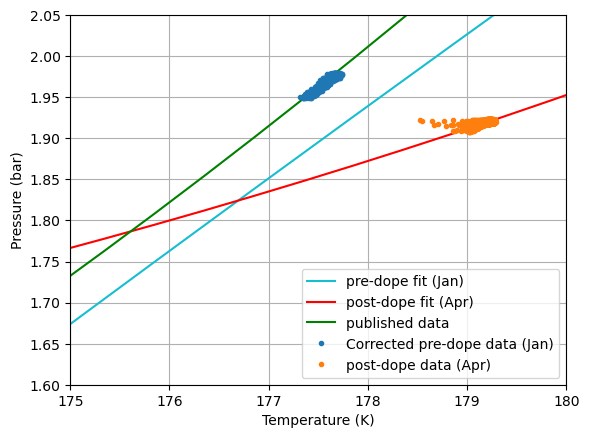

In [75]:
gasfit = pt_func_p_adj(temp, popt[0], popt[1], popt[2], popt[3])
gas_ideal = pt_func_p_adj(temp, idealt[0], idealt[1], idealt[2], idealt[3])
p_ideal = pt_func_p_adj(t, idealt[0], idealt[1], idealt[2], idealt[3])
p_post = pt_func_p_adj(temp, popp[0], popp[1], popp[2], popp[3])

plt.plot(temp, gasfit, color='C9', label='pre-dope fit (Jan)')
plt.plot(temp, p_post, color='r', label='post-dope fit (Apr)')
plt.plot(temp, gas_ideal, color='g', label='published data')
plt.plot(t, 1.035*p, '.', label='Corrected pre-dope data (Jan)')
plt.plot(t_p, p_p, '.', label='post-dope data (Apr)')
#plt.plot(pt_func_p_adj(t_p, idealt[0], idealt[1], idealt[2], idealt))
plt.xlabel("Temperature (K)")
plt.ylabel("Pressure (bar)")
plt.xlim(175, 180)
plt.ylim(1.60, 2.05)
plt.legend()
plt.grid()
plt.show()

In [235]:
p_pure = p[(t > 177.5) & (t < 177.8)]
p_post = p_p[(t_p > 177.5) & (t_p < 177.8)]
diff = np.mean(p_post) - np.mean(p_pure)

In [236]:
print(diff)

0.020546126236989037


In [368]:
x = np.arange(177.3, 177.8, 0.01)
y1 = pt_func_p(x, popt[0], popt[1], popt[2])
y2 = pt_func_p(x, popp[0], popp[1], popp[2])

In [374]:
print(np.mean(y2 - y1))

0.013908889824121785
